# Employee Training Causal Analysis
## 1. Business question
Did employee training improve store sales? This retail panel covers 50 stores over 24 months. Training begins in January 2025. The analysis combines descriptive evidence, regression, panel models, and TWFE difference-in-differences to inform a phased rollout decision. Causal interpretation requires explicit assumptions; sales units cannot be translated into profit or ROI with the available data.


In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image
candidate = Path.cwd().resolve()
ROOT = candidate if (candidate / 'src').is_dir() else candidate.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Launch from the repository root or notebooks directory.')
sys.path.insert(0, str(ROOT))
from src.run_analysis import run_analysis
from src.regression_models import coefficient_table


## 2. Data loading
The course-provided workbook contains a balanced store-month panel. The pipeline checks CSV values against the workbook without modifying observations, and generates all analysis outputs using project-relative paths.


In [2]:
analysis = run_analysis()
df, tables = analysis['df'], analysis['tables']
ols, models, did = analysis['ols'], analysis['models'], analysis['did']
display(df.head())


              coefficient  standard_error       p_value  ci_lower  ci_upper
treated:post     5.185167        0.382603  7.673052e-42  4.435279  5.935054
                                             test  statistic  df_num  df_den       p_value                           status                                                                                                     interpretation  minimum_covariance_difference_eigenvalue covariance_positive_definite
Classical F comparison of pooled OLS and store FE  50.216088      48  1146.0 3.469115e-245              Classical inference                    Evidence of store heterogeneity under classical F assumptions; not a cluster-robust joint test.                                       NaN                          NaN
         Standard Hausman comparison of FE and RE        NaN       4     NaN           NaN Chi-square inference unavailable Covariance difference is indefinite or singular; no validated chi-square inference or rejection of RE co

,store_id,month,treated,post,staff_num,avg_price,competitor_num,sales
0,1,1,0,0,0,21.81,3,51.80
1,2,1,0,0,5,15.66,2,53.37
2,3,1,1,0,4,23.77,2,53.87
3,4,1,0,0,4,20.36,2,59.53
4,5,1,1,0,6,22.79,1,54.71


## 3. Data quality
Validate 1,200 observations, 50 stores, months 1–24, unique store-month keys, no missing analysis values, and stable treatment status. There are 25 treated and 25 control stores. Month 13 begins the post period. Calendar labels follow supplied period metadata.


In [3]:
display(tables['data_quality'])
display(df[['sales','staff_num','avg_price','competitor_num']].describe())

,check,passed
0,"1,200 observations",True
1,50 stores,True
2,Months 1 through 24,True
3,No missing analysis values,True
4,Unique store-month keys,True
5,24 months per store,True
6,Binary treatment,True
7,Treatment constant within store,True
8,Post begins in month 13,True
9,25 treated and 25 control stores,True


,sales,staff_num,avg_price,competitor_num
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,58.835492,5.809167,21.046400,2.036667
std,6.231912,2.074770,2.414973,1.025280
min,41.440000,0.000000,14.310000,0.000000
25%,54.437500,4.000000,19.690000,1.000000
50%,58.805000,6.000000,21.420000,2.000000
75%,63.270000,7.000000,22.722500,3.000000
max,75.960000,11.000000,26.060000,5.000000


## 4. Exploratory analysis
Sales distributions describe all store-month observations and mix pre- and post-training periods. Distribution differences are descriptive evidence.


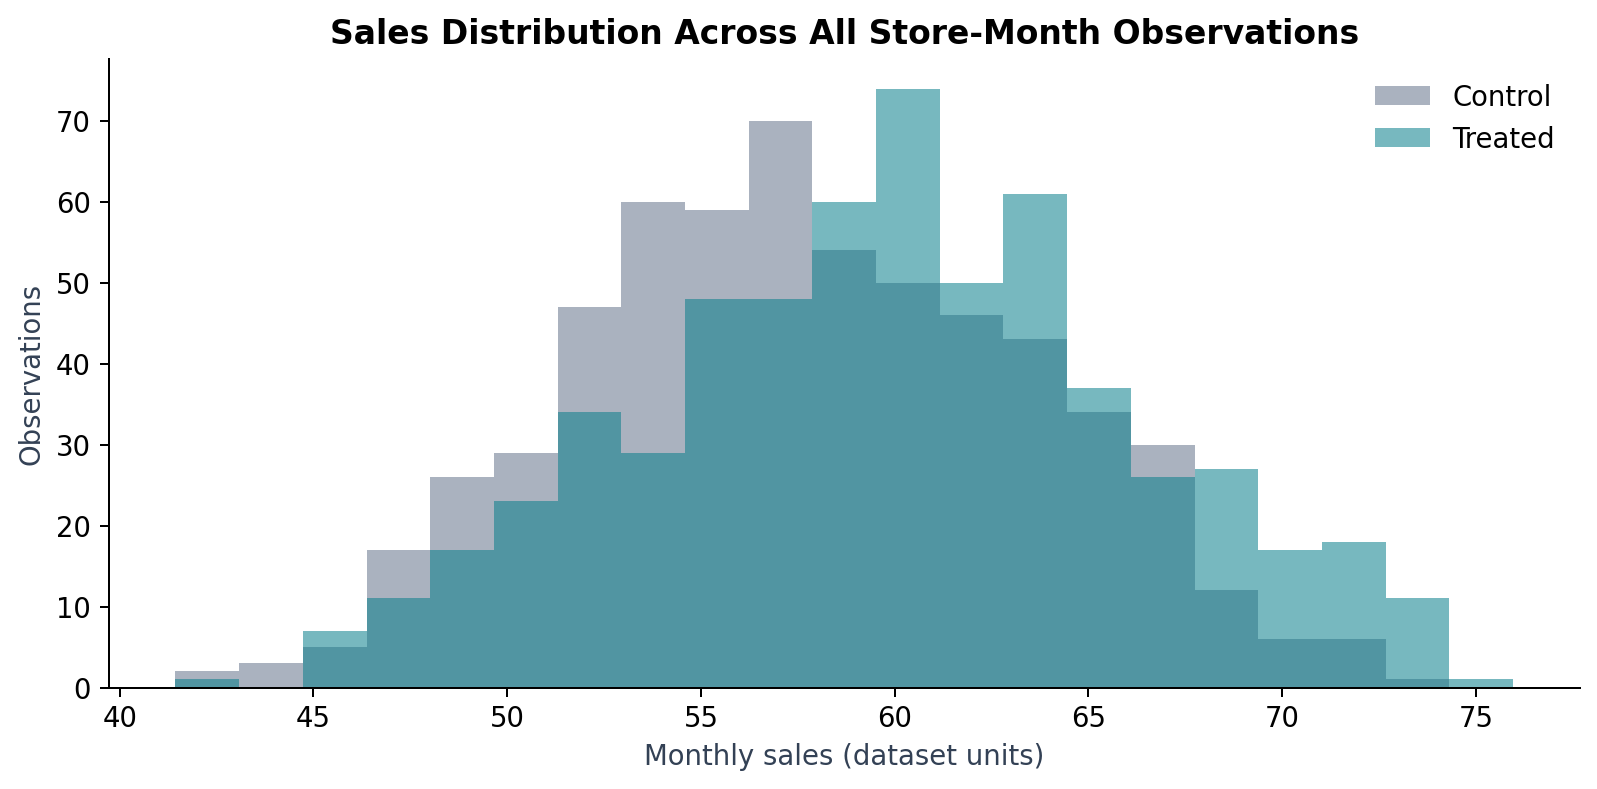

In [4]:
display(Image(filename=str(ROOT / 'outputs/figures/sales_distribution.png')))

## 5. Group and period statistics
Compare sales across treatment groups and periods. The difference in changes provides a descriptive starting point, but can also reflect time-varying confounding.


In [5]:
display(tables['descriptive_statistics'].round(4))
means = tables['descriptive_statistics'].pivot(index='treated', columns='post', values='mean')
raw_did = (means.loc[1,1]-means.loc[1,0])-(means.loc[0,1]-means.loc[0,0])
print(f'Descriptive difference in changes: {raw_did:.4f} sales units')


,treated,post,count,mean,median,std,min,max,IQR,skew,group,period
0,0,0,300,56.9086,56.360,5.7555,44.20,71.48,8.9275,0.2036,Control,Pre-training
1,0,1,300,58.6025,58.150,5.8919,41.44,73.00,8.0975,-0.0730,Control,Post-training
2,1,0,300,56.4759,56.555,5.4247,43.05,68.51,8.1700,-0.0445,Treated,Pre-training
3,1,1,300,63.3550,63.265,5.3487,49.81,75.96,7.5950,0.0878,Treated,Post-training


Descriptive difference in changes: 5.1852 sales units


## 6. Hypothesis testing
The Welch test compares each store's average sales across its 12 post-training months, with 25 store summaries per group. The p-value of approximately 0.0013 indicates a post-period group difference; it does not establish a causal training effect.


In [6]:
display(tables['welch_ttest'])

,test,statistic,p_value,control_stores,treated_stores
0,Store-level Welch t-test,-3.424574,0.001292,25,25


## 7. Pooled OLS
Sales is modelled using treated, post, staff count, average price, and competitor count. The treated coefficient is a conditional group difference across the full observation period, not a DID treatment effect. Conventional OLS standard errors are used for this exploratory comparison.


In [7]:
display(tables['ols_results'].round(6))
print(f'R-squared: {ols.rsquared:.4f}; adjusted: {ols.rsquared_adj:.4f}; F: {ols.fvalue:.4f}')

,coefficient,standard_error,p_value,ci_lower,ci_upper
const,46.899389,1.527867,0.000000,43.901786,49.896992
treated,2.024340,0.333206,0.000000,1.370605,2.678075
post,3.238527,0.350325,0.000000,2.551205,3.925849
staff_num,0.612727,0.087233,0.000000,0.441580,0.783874
avg_price,0.207119,0.069588,0.002976,0.070591,0.343646
competitor_num,0.680590,0.172436,0.000084,0.342279,1.018901


R-squared: 0.1915; adjusted: 0.1881; F: 56.5631


## 8. Regression diagnostics
VIF values are below 2. Residual Q-Q and residual-versus-fitted plots assess distribution and functional form. Visual checks do not prove independence or all regression assumptions. Store clustering is used for FE coefficients and the main DID estimate.


,variable,VIF
0,treated,1.056
1,post,1.168
2,staff_num,1.246
3,avg_price,1.074
4,competitor_num,1.189


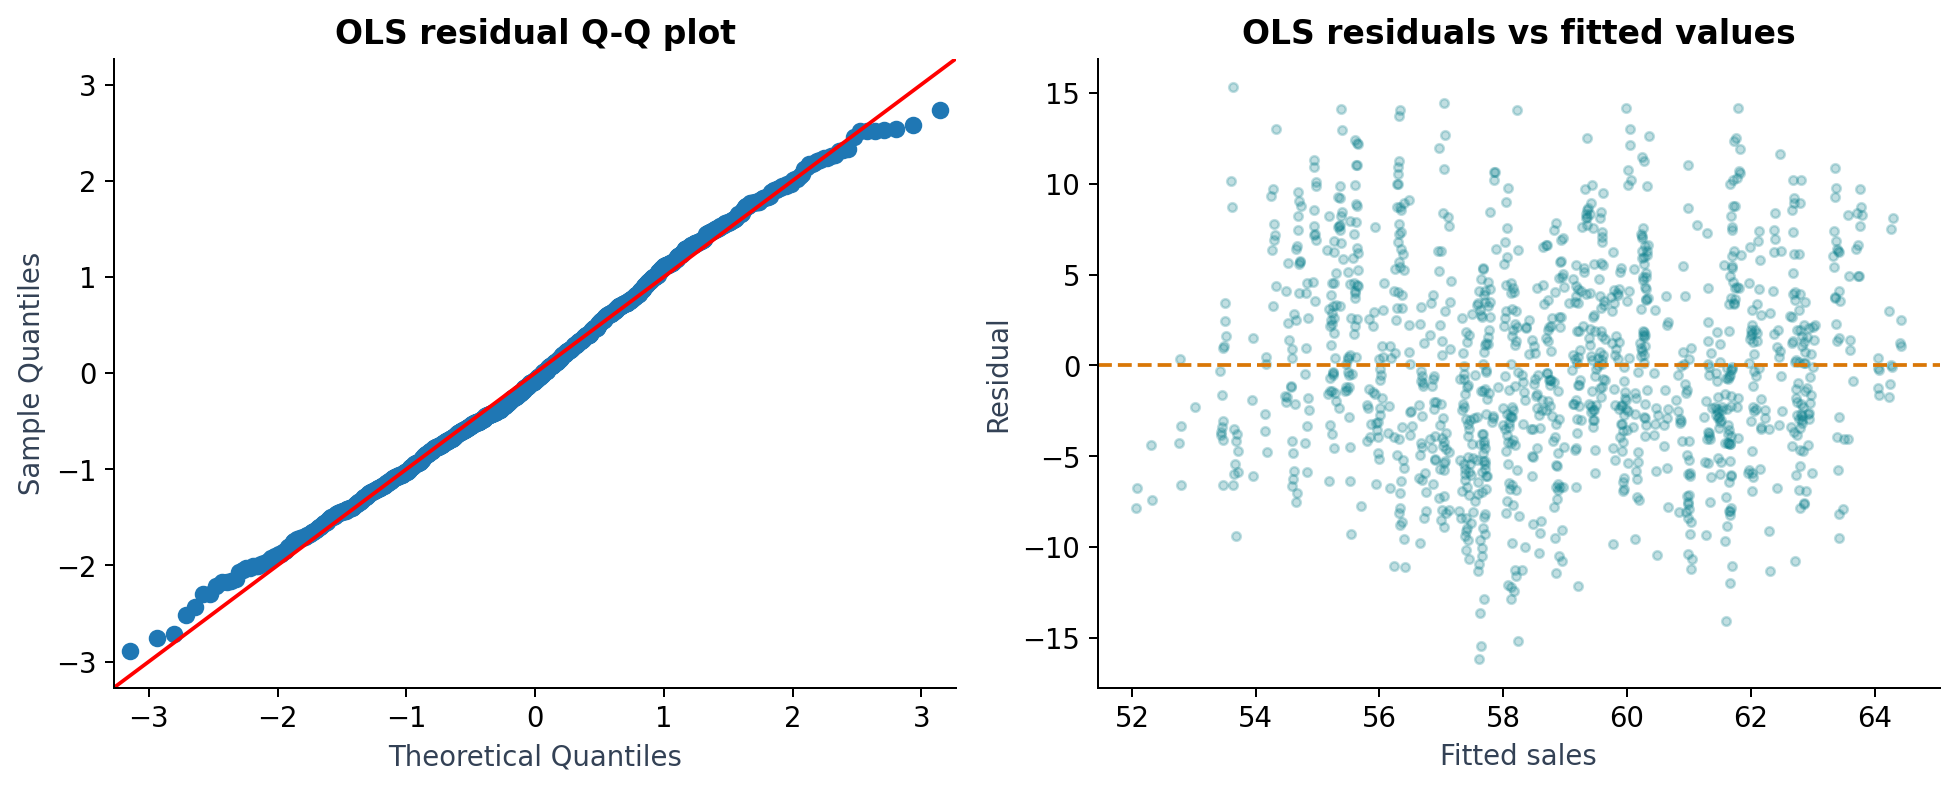

In [8]:
display(tables['vif'].round(3))
display(Image(filename=str(ROOT / 'outputs/figures/regression_diagnostics.png')))

## 9. Panel models
Pooled OLS combines within-store and between-store variation. Store FE estimates within-store associations while controlling persistent store characteristics. Time-invariant treated is absorbed by store FE.

Random Effects is estimated with an intercept using the RandomEffects estimator. It assumes store effects are uncorrelated with the regressors. Its treated coefficient is approximately 1.8376, with p ≈ 0.194. Different estimators use different R-squared definitions; these values are not a single model-ranking criterion.


In [9]:
display(tables['model_comparison'].round(6))
display(tables['model_fit'].round(6))

coefficient  standard_error   p_value  \
model          variable                                                
Pooled OLS     const             46.899389        1.527867  0.000000   
               treated            2.024340        0.333206  0.000000   
               post               3.238527        0.350325  0.000000   
               staff_num          0.612727        0.087233  0.000000   
               avg_price          0.207119        0.069588  0.002976   
               competitor_num     0.680590        0.172436  0.000084   
Store FE       post               2.691914        0.516124  0.000000   
               staff_num          0.153277        0.313911  0.625443   
               avg_price          2.100190        0.837321  0.012271   
               competitor_num     0.562873        0.605755  0.352976   
Random Effects const             42.717856        5.417749  0.000000   
               treated            1.837608        1.414340  0.194102   
               post               3.090746        0.309878  0.000000   
               staff_num          0.633841        0.190620  0.000911   
               avg_price          0.407143        0.276181  0.140694   
               competitor_num     0.688616        0.324218  0.033881   

                                ci_lower   ci_upper  
model          variable                              
Pooled OLS     const           43.901786  49.896992  
               treated          1.370605   2.678075  
               post             2.551205   3.925849  
               staff_num        0.441580   0.783874  
               avg_price        0.070591   0.343646  
               competitor_num   0.342279   1.018901  
Store FE       post             1.679260   3.704568  
               staff_num       -0.462627   0.769182  
               avg_price        0.457336   3.743044  
               competitor_num  -0.625640   1.751386  
Random Effects const           32.088487  53.347224  
               treated         -0.937260   4.612476  
               post             2.482779   3.698712  
               staff_num        0.259854   1.007827  
               avg_price       -0.134711   0.948996  
               competitor_num   0.052516   1.324717

,model,r_squared,adjusted_r_squared,note
0,Pooled OLS,0.191504,NaN,Estimator-specific R-squared; not directly com...
1,Store FE,0.322948,NaN,Within R-squared
2,Random Effects,0.314420,NaN,Estimator-specific R-squared; not directly com...
3,TWFE DID,0.786163,0.772299,Estimator-specific R-squared; not directly com...


## 10. Model selection and interpretation
The classical F comparison of pooled OLS and store FE provides evidence that store-level heterogeneity is important: F ≈ 50.22, p < 0.001. It relies on classical F-test assumptions and is not a cluster-robust joint test.

The standard Hausman comparison has an indefinite covariance-difference matrix, so validated chi-square inference is unavailable. It does not statistically reject RE consistency or prove FE superior.

**FE is retained primarily because the research design focuses on within-store changes over time.** Persistent unobserved differences across stores are substantively important; store fixed effects control time-invariant heterogeneity.

Staffing and competitor count become statistically insignificant under FE, suggesting some pooled associations may reflect persistent cross-store differences. Average price and post remain positively associated with sales. These associations are not independently established causal effects; post also includes training exposure across the sample.


In [10]:
display(tables['model_selection'])
display(coefficient_table(models['Store FE']).round(6))

,test,statistic,df_num,df_den,p_value,status,interpretation,minimum_covariance_difference_eigenvalue,covariance_positive_definite
0,Classical F comparison of pooled OLS and store FE,50.216088,48,1146.0,3.469115e-245,Classical inference,Evidence of store heterogeneity under classica...,NaN,NaN
1,Standard Hausman comparison of FE and RE,NaN,4,NaN,NaN,Chi-square inference unavailable,Covariance difference is indefinite or singula...,-0.000004,False


,coefficient,standard_error,p_value,ci_lower,ci_upper
post,2.691914,0.516124,0.000000,1.679260,3.704568
staff_num,0.153277,0.313911,0.625443,-0.462627,0.769182
avg_price,2.100190,0.837321,0.012271,0.457336,3.743044
competitor_num,0.562873,0.605755,0.352976,-0.625640,1.751386


## 11. Difference in differences
The identified model is `sales ~ treated:post + C(store_id) + C(month)`. Store effects control stable store differences; month effects control shocks common to stores in a month. The treated and post main effects are absorbed by these effects. Store-clustered standard errors allow dependence within each store over time, with normal-reference confidence intervals for the treatment estimate.

Average price is a store-specific level plus a common monthly change and is fully absorbed by these fixed effects, so no separate price coefficient is estimated. Staffing and competitor count are excluded from the parsimonious model, but insignificant coefficients alone do not rule out confounding.


In [11]:
display(tables['twfe_did_results'])
print(f'TWFE R-squared: {did.rsquared:.4f}; adjusted: {did.rsquared_adj:.4f}')
display(tables['time_effects_test'])
display(tables['design_diagnostics'])

,coefficient,standard_error,p_value,ci_lower,ci_upper
treated:post,5.185167,0.382603,7.673052e-42,4.435279,5.935054


TWFE R-squared: 0.7862; adjusted: 0.7723


,test,statistic,p_value,df_num,df_den
0,Store-clustered joint test of month effects,4.857384,0.000002,23.0,49


,model,design_columns,design_rank,full_column_rank,max_abs_price_residual_after_store_month_FE,price_interpretation
0,TWFE DID,74,74,True,2.273737e-13,Price variation is absorbed by store and month...


### Supplemental baseline DID
The baseline model estimates the treatment interaction with group and post indicators and operational covariates, using store-clustered standard errors. It does not include store and month effects; the TWFE model remains the primary evaluation.


In [12]:
display(tables['basic_did_results'].round(6))

,coefficient,standard_error,p_value,ci_lower,ci_upper
Intercept,48.266374,7.121849,0.000000,34.307806,62.224942
treated,-0.533916,1.388665,0.700622,-3.255649,2.187817
post,0.713547,0.645947,0.269310,-0.552486,1.979580
treated:post,5.094821,0.375324,0.000000,4.359199,5.830443
staff_num,0.603178,0.322216,0.061211,-0.028353,1.234710
avg_price,0.209566,0.303476,0.489848,-0.385237,0.804368
competitor_num,0.633893,0.593979,0.285882,-0.530283,1.798070


## 12. Parallel trends
Monthly group means and group differences show broadly similar pre-training trends and an upward divergence among trained stores afterward. This is a descriptive assessment, not a formal event-study regression or proof of counterfactual parallel trends.


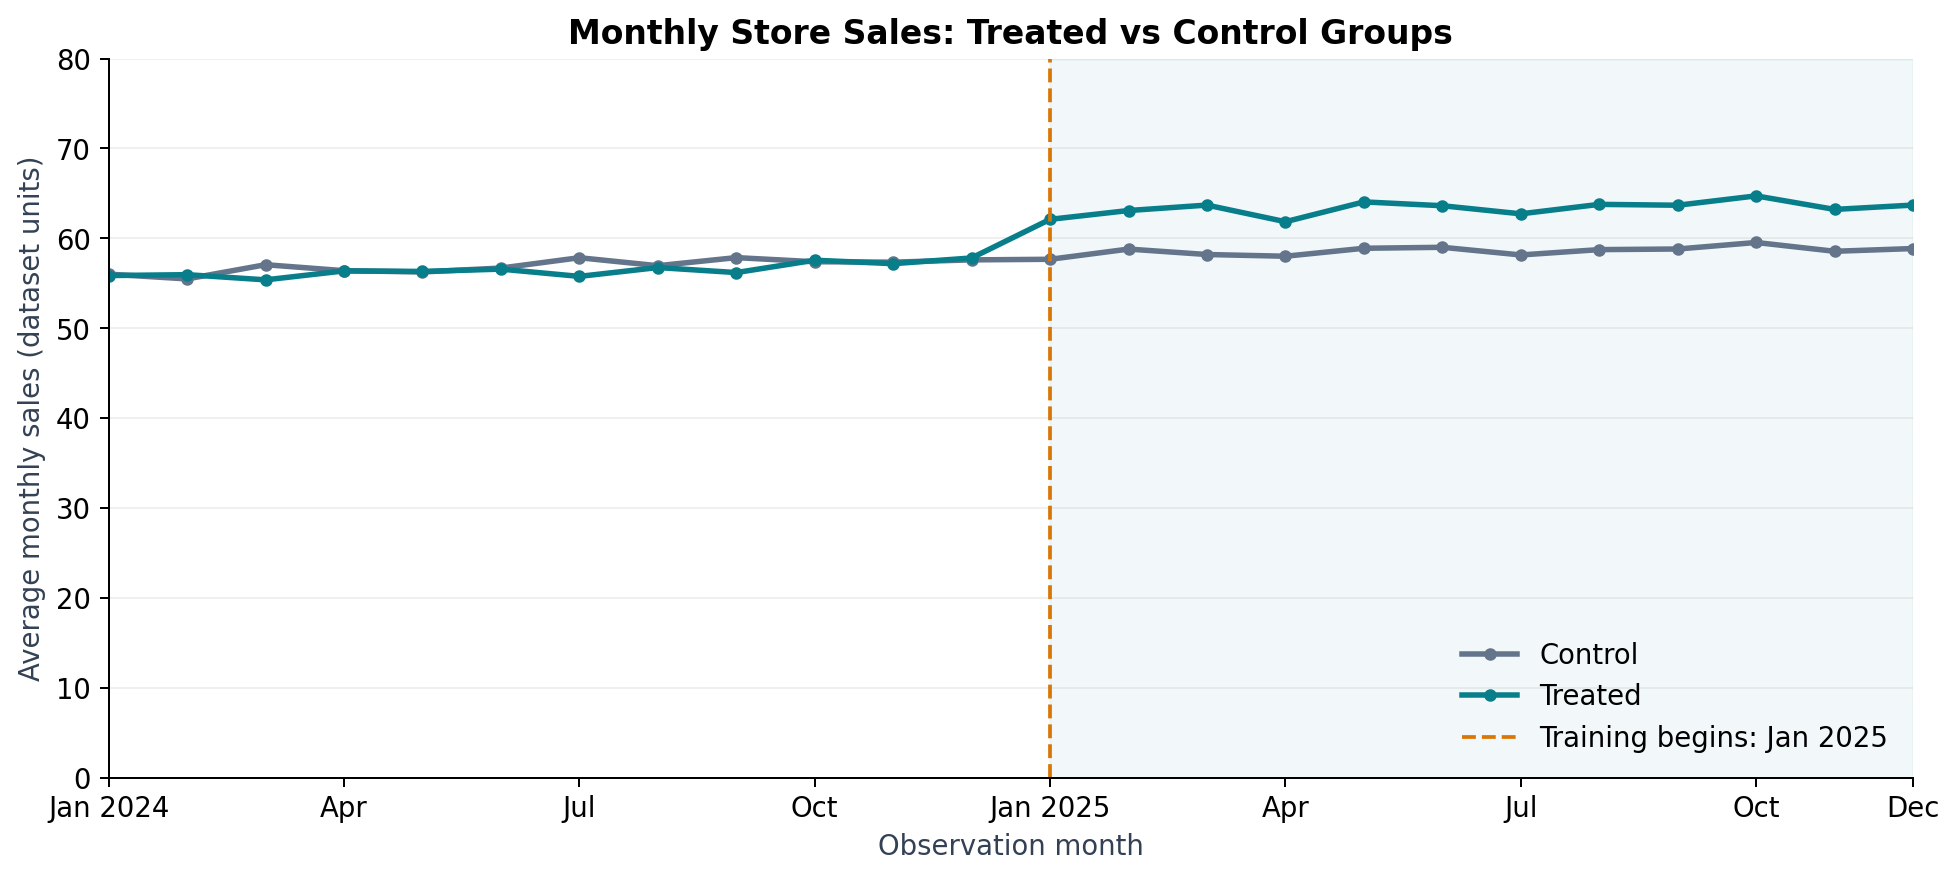

,control,treated,difference
month,,,
1,56.0160,55.8564,-0.1596
2,55.4832,55.9552,0.4720
3,57.0640,55.3792,-1.6848
4,56.4008,56.3736,-0.0272
5,56.2560,56.3128,0.0568
6,56.6916,56.5724,-0.1192
7,57.8404,55.7656,-2.0748
8,56.9536,56.7484,-0.2052
9,57.8528,56.1888,-1.6640


In [13]:
display(Image(filename=str(ROOT / 'outputs/figures/monthly_sales_trends.png')))
display(tables['monthly_trends'].round(4))

## 13. Business interpretation
The training estimate is approximately +5.19 monthly sales units, with 95% confidence interval [4.44, 5.94]. Under parallel trends and other maintained assumptions, this supports a phased expansion in comparable stores. Track sales and operations, retain credible comparison stores, and assess costs and margins before scaling. Communication, product presentation, and higher-value recommendations can be tested as complementary initiatives; price associations do not establish a causal pricing opportunity.


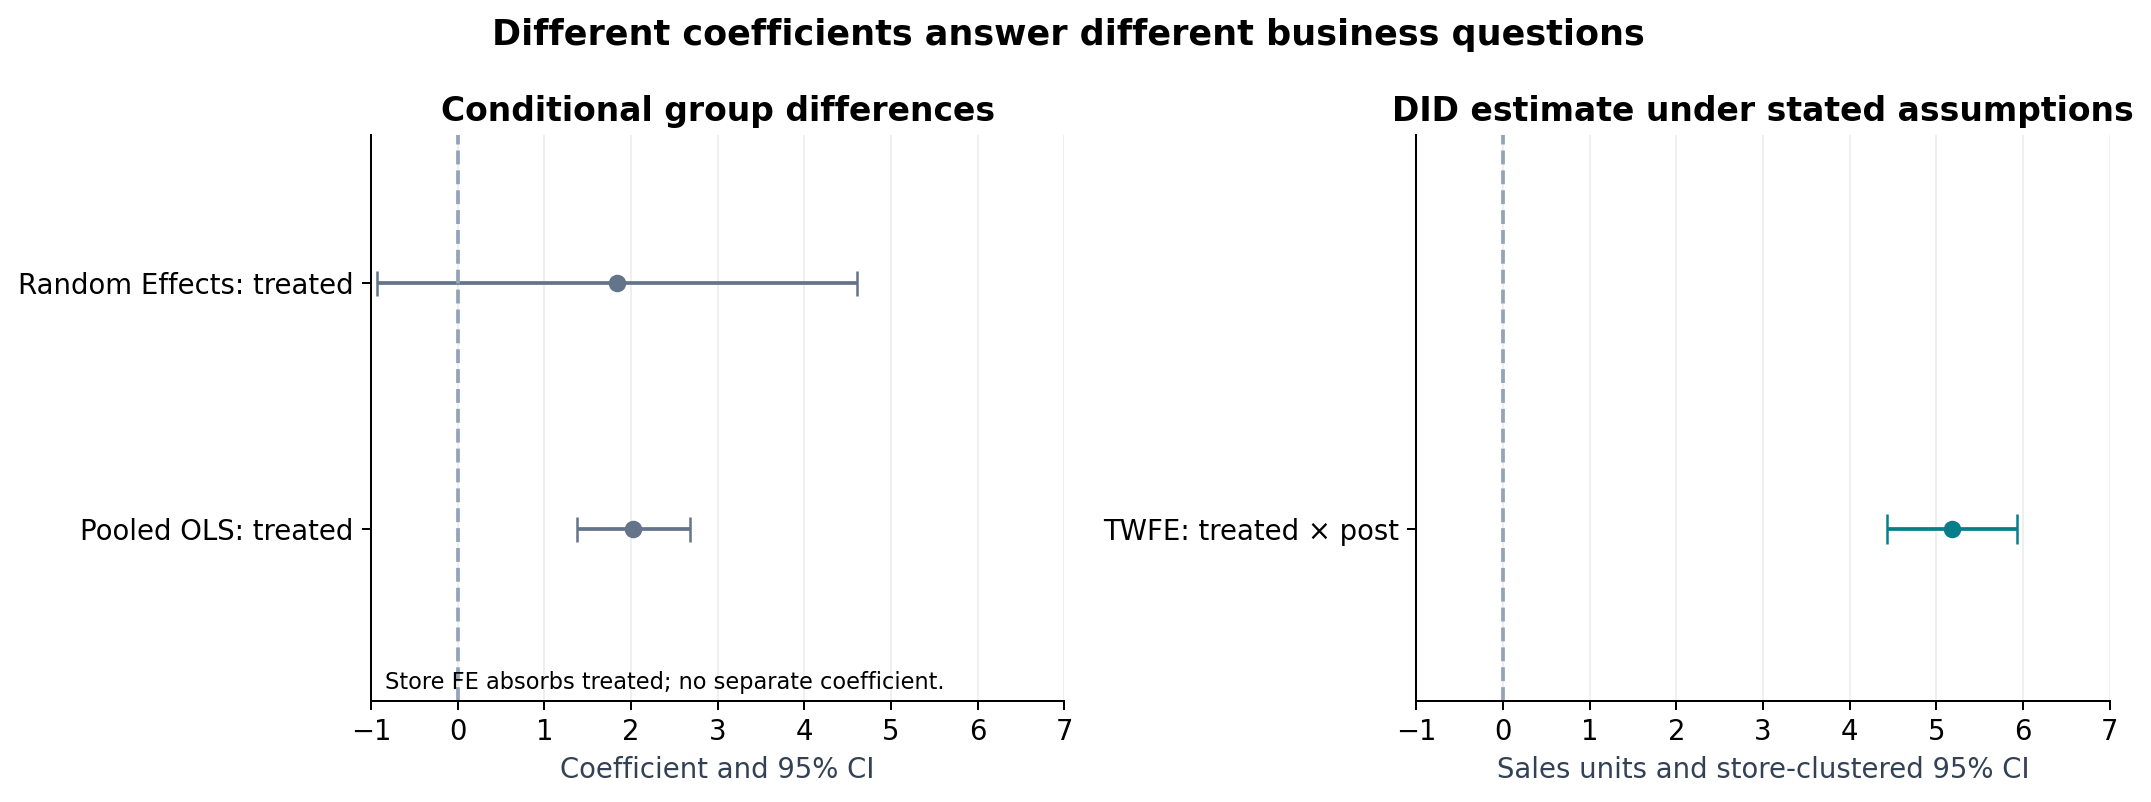

In [14]:
display(Image(filename=str(ROOT / 'outputs/figures/model_comparison.png')))

## 14. Limitations
Training is not randomly assigned. Selection into training, unobserved time-varying differences, concurrent interventions, external shocks, anticipation, and spillovers can violate DID assumptions. The sample covers only 12 pre- and 12 post-treatment months, limiting long-term assessment and generalisation. Costs, margins, geographic information, and concurrent intervention records are unavailable. The Hausman comparison does not provide validated chi-square inference. No causal effect of pricing is independently established.

## 15. Potential IV and 2SLS extension
Distance to the nearest training centre is a proposed instrument because travel and scheduling costs could affect participation. **IV/2SLS was not estimated because distance data are unavailable.** No IV coefficient or first-stage F-statistic is reported. Relevance, exogeneity, and exclusion remain untested; geography can also affect demand. A panel extension would instrument treated × post with distance × post, subject to a defensible exclusion restriction and appropriate two-stage inference.

## 16. Conclusion
The evidence suggests a +5.19-unit monthly training effect under explicit DID assumptions. The business recommendation is monitored phased expansion with an economic evaluation. The complete report in `../report/employee_training_analysis_report.md` presents the final methodology and findings. No formal event study, placebo, geographic spillover regression, or IV estimation is claimed as completed.
